<a href="https://colab.research.google.com/github/ValeriaGomez13/Diplomado/blob/Modelos-Estadisticos/Espacios_de_probabilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probabilidad Laplaciana (clásica)

Para un experimento aleatorio, se tiene que $\Omega$ es el espacio muestral.
Sea $A$ un evento, entonces

$$ \mathbb{P}(A) = \frac{\#A}{\#\Omega} $$
(casos favorables entre casos totales)

Donde $\#A$ denota la cardinalidad o número de elementos del conjunto $A$.

Podemos aplicar esta definicion de probabilidad cuando:
- El espacio muestral es finito.
- El espacio muestral es equiprobable, es decir, todos los elementos tienen el mismo "peso".

**Ejemlo:**

Sea el experimento de lanzar una moneda 3 veces, de manera independiente (es decir, el $i$-esimo lanzamiento no me afecta al $i+1$). El espacio muestral es el siguiente:

$$ \Omega = \{A, S\} \times \{A, S\} \times \{A, S\} = \{A, S\}^3 $$
y tenemos que $\#\Omega = 2^3$.

Sean los eventos:
* $A$: Todos los resultados son águila
* $S$: Todos los resultados son soles
* $E$: Por lo menos un resultado es sol \\
Calcular las probabilidades de estos eventos

**Solucion:** \\
Vamos a descomponer mi conjunto $A$ de la siguiente manera:
$$ A = A_1 \cap A_2 \cap A_3 $$
donde  $A_i$: cae águila en el $i$-ésimo resultado.

In [ ]:
# Creacion del espacio muestral
import itertools #importamos el modulo
from itertools import product

In [ ]:
omega = set(product({"A","S"}, repeat = 3)) #producto cartesiano de nuetsro conjunto repetido 3 veces
omega

{('A', 'A', 'A'),
 ('A', 'A', 'S'),
 ('A', 'S', 'A'),
 ('A', 'S', 'S'),
 ('S', 'A', 'A'),
 ('S', 'A', 'S'),
 ('S', 'S', 'A'),
 ('S', 'S', 'S')}

In [ ]:
len(omega)

8

In [ ]:
#Vamos a crear el evento A_1
A_1 = { om for om in omega if om[0]=="A"} #La primera coordenada es águila
A_1

{('A', 'A', 'A'), ('A', 'A', 'S'), ('A', 'S', 'A'), ('A', 'S', 'S')}

In [ ]:
#Vamos a crear el evento A_2
A_2 = { om for om in omega if om[1]=="A"} #La segunda coordenada es águila
A_2

{('A', 'A', 'A'), ('A', 'A', 'S'), ('S', 'A', 'A'), ('S', 'A', 'S')}

In [ ]:
#Vamos a crear el evento A_3
A_3 = { om for om in omega if om[2]=="A"} #La tercera coordenada es águila
A_3

{('A', 'A', 'A'), ('A', 'S', 'A'), ('S', 'A', 'A'), ('S', 'S', 'A')}

In [ ]:
# Vamos a crear el evento A
# Interseccion de los eventos A_1, A_2 y A_3
A = A_1.intersection(A_2.intersection (A_3))
A

{('A', 'A', 'A')}

In [ ]:
len(A)

1

In [ ]:
#Vamos a calcular la probabilidad de A
P_A = len(A) / len(omega)
P_A

0.125

Para expresar mi resultado en fracción:

In [ ]:
from fractions import Fraction

def p(E,omega):
  p = Fraction(len(E),len(omega))
  return p

In [ ]:
prob = p(A, omega)
prob

Fraction(1, 8)

Vamos a descomponer mi conjunto $S$ de la siguiente manera:
$$ S = S_1 \cap S_2 \cap S_3 $$
donde  $S_i$: cae son en el $i$-ésimo resultado.

In [ ]:
#Creamos el evento S_1
S_1 = {om for om in omega if om[0]=="S"} #La primer coordenada sea Sol
S_1

{('S', 'A', 'A'), ('S', 'A', 'S'), ('S', 'S', 'A'), ('S', 'S', 'S')}

In [ ]:
#Creamos el evento S_2
S_2 = {om for om in omega if om[1]=="S"} #La segunda coordenada sea Sol
S_2

{('A', 'S', 'A'), ('A', 'S', 'S'), ('S', 'S', 'A'), ('S', 'S', 'S')}

In [ ]:
#Creamos el evento S_3
S_3 = {om for om in omega if om[2]=="S"} #La tercera coordenada sea Sol
S_3

{('A', 'A', 'S'), ('A', 'S', 'S'), ('S', 'A', 'S'), ('S', 'S', 'S')}

In [ ]:
#Creamos el evento S
#Interseccion de los eventos S_1, S_2 y S_3
S = S_1.intersection(S_2.intersection(S_3))
S

{('S', 'S', 'S')}

In [ ]:
len(S)

1

In [ ]:
#Calculamos la probabilidad de S
P_S = len(S)/len(omega)
P_S

0.125

Para el evento $E$ son todos menos donde todos los resultados son Aguila, es decir:
$$E = \Omega - A$$

In [ ]:
#Calculamos el evento E
E = omega - A
E

{('A', 'A', 'S'),
 ('A', 'S', 'A'),
 ('A', 'S', 'S'),
 ('S', 'A', 'A'),
 ('S', 'A', 'S'),
 ('S', 'S', 'A'),
 ('S', 'S', 'S')}

In [ ]:
len(E)

7

In [ ]:
#Calculamos la probabilidad de E
P_E = len(E)/len(omega)
P_E

0.875

## Probabilidad Condicional

Definimos la probabilidad de que ocurra un evento $A$ sabiendo que ocurre el evento $B$,

$$ \mathbb{P}(A \mid B) = \frac{\mathbb{P}(A \cap B)}{\mathbb{P}(B)} = \frac{\#A \cap B}{\#B} $$
donde $\mathbb{P}(B) > 0$

Se lee como " *Probabilidad de A dado B* "

In [ ]:
# Funcion para la probabilidad condicional
def prob_cond(E,F):
  return len(E & F) / len(F)
  # & hace interseccion unicamente entre dos conjuntos, si se hara de mas de dos usar intersection

Calcular la probabilidad condicional de los siguientes eventos:
* El primer lanzamiento es águila
* Dos de los resultados son águila

In [ ]:
# Definimos el evento B: El primer lanzamiento es aguila
B = {om for om in omega if om[0]=="A"}
B

{('A', 'A', 'A'), ('A', 'A', 'S'), ('A', 'S', 'A'), ('A', 'S', 'S')}

In [ ]:
# Definimos el evento C: Dos resultados sean águila
C = {om for om in omega if om.count("A")==2}
C

{('A', 'A', 'S'), ('A', 'S', 'A'), ('S', 'A', 'A')}

In [ ]:
# Funcion de probabilidad clásica
def prob(E):
  return len(E)/len(omega)

In [ ]:
# Probabilidad de que el primer lanzamiento sea águila
prob(B)

0.5

In [ ]:
# Probabilidad de que dos lanzamientos sean águila
prob(C)

0.375

In [ ]:
# Probabilidad de que el primer lanzamiento sea águila dado que dos lanzamientos son águila
prob_cond(B,C)

0.6666666666666666

## Independencia de eventos

Decimos que dos eventos $A$ y $B$ son independientes si $$ \mathbb{P}(A \cap B) = \mathbb{P}(A)\mathbb{P}(B) $$
o de manera equivalente
$$ \mathbb{P}(A|B) = \mathbb{P}(A) $$
Lo que significa que la ocurrencia del evento $B$ no afecta la probabilidad del evento $A$.
Ánalogicamente
$$ \mathbb{P}(B|A) = \mathbb{P}(B) $$
Es decir, la ocurrencia del evento A no cambia la probabilidad de B.

In [ ]:
# Función para verficar la independencia de eventos
def indep(E,F):
  return prob(E & F) == prob(E)*prob(F)

In [ ]:
# Verificamos si la probabilidad de que el primer lanzamiento sea águila depende de que dos lanzamientos sean águila
indep(B,C)

False

* $D$: en el segundo lanzamiento es sol

In [ ]:
# Definimos el evento D: el segundo lanzamiento es Sol
D = {om for om in omega if om[1]=="S"}
D

{('A', 'S', 'A'), ('A', 'S', 'S'), ('S', 'S', 'A'), ('S', 'S', 'S')}

In [ ]:
prob(D)

0.5

In [ ]:
# Probabilidad de que el primer lanzamiento sea águila dado que el segundo es sol
prob_cond(B,D)

In [ ]:
# Verificamos si la probabilidad de que el primer lanzamiento sea águila depende de que el segundo sea sol
indep(B,D)

True

Quiero verificar si B, C y D son independientes
Para esto:
$$ \mathbb{P}(B \cap C \cap D) = \mathbb{P}(B)\mathbb{P}(C)\mathbb{P}(D) $$
Además
$$ \mathbb{P}(B \cap C) = \mathbb{P}(B)\mathbb{P}(C) $$
$$ \mathbb{P}(C \cap D) = \mathbb{P}(C)\mathbb{P}(D) $$
$$ \mathbb{P}(B \cap D) = \mathbb{P}(B)\mathbb{P}(D) $$
Es decir, verificar que el evento $B$ sea independiente del evento $C$, el evento $C$ sea independiente del evento $D$ y asi mismo que el evento $B$ sea independiente del evento $D$

In [ ]:
indep(B,D)

True

In [ ]:
indep(C,D)

False

In [ ]:
indep(B,C)

False

Por lo tanto, los eventos no son independientes.

**EJEMPLO**

Sea el experimento aleatorio de lanzar un dado dos veces. Sabemos que el espacio muestral es el siguiente:

$$ \Omega = \{ (i,j) | i,j \in \{1, 2, 3, 4, 5, 6 \} \} = \{1, 2, 3, 4, 5, 6 \} \times \{1, 2, 3, 4, 5, 6 \} = \{1, 2, 3, 4, 5, 6 \}^2 $$

y además $\#\Omega = 6^2 = 36$


In [ ]:
# Definimos el espacio muestral Omega
Omega_dado = set(product([1, 2, 3, 4, 5, 6], repeat=2))
print(Omega_dado)

{(3, 4), (4, 3), (3, 1), (5, 4), (4, 6), (5, 1), (2, 2), (1, 6), (2, 5), (1, 3), (6, 2), (6, 5), (4, 2), (4, 5), (3, 3), (5, 6), (3, 6), (5, 3), (2, 4), (1, 2), (2, 1), (1, 5), (6, 1), (6, 4), (3, 2), (4, 1), (3, 5), (5, 2), (4, 4), (5, 5), (1, 1), (1, 4), (2, 3), (2, 6), (6, 6), (6, 3)}


In [ ]:
# Cardinalidad de Omega
cardOm = len(Omega_dado)
cardOm

36

Definimos el evento
* $S_n$ : la suma de los dados en $n$
y escrito como conjunto es
$$ S_n = \{ (i, j)\in\Omega \mid i+j = n \}$$

In [ ]:
# Definimos el evento S_n
def S(n):
  Sn = { (i,j) for i in range(1,7) for j in range(1,7) if i+j == n}
  return Sn

In [ ]:
# Definimos la funcion de probabilidad para el dado
def prob_D(D):
  return len(E)/len(Omega_dado)

In [ ]:
S_nueve = S(9)
S_nueve

{(3, 6), (4, 5), (5, 4), (6, 3)}

In [ ]:
prob_D(S_nueve)

0.19444444444444445

# Probabilidad geométrica

Ahora la probabilidad de un evento se medira a través de su área, volumen o alguna característica geométrica equivalente y no mediante su cardinalidad.

Si un experimento aleatorio tiene como espacio muestral $\Omega \subseteq \mathbb{R}^2$ cuya área esta bien definida y es finita, entonces se define la probabilidad geométrica de un evento $A \subseteq \Omega$ como:
$$ \mathbb{P}(A) = \frac{\text{Área de } A}{\text{Área de } \Omega} $$

NOTA: Puede usarse tambien cuando $\Omega \subseteq \mathbb{R}$ y se habla de longitud y cuando $\Omega \subseteq \mathbb{R}^3$ hablando de volumen.



## Ejemplo: el problema del encuentro

Romeo y Julieta pretenden encontrarse en un lugar especifico entre $[0,60]$
- Si Romeo llega primero, entonces piensa esperar 10 minutos
- Si Julieta llega primero, entonces piensa esperar 10 minutos
Se elige un número al azar entre $0$ y $60$, y supongamos que el par de numeros se elige sobre el cuadrado $60^2$, de modo que la probabilidad de un evento, sea el área favorable entre el área total.

Sea el evento A
- $A$: Romeo y Juliera se encuentran a una distancia de $10$ minutos.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Vamos a general 100,00 simulaciones
muestra = 100000

# Generamos los tiempos aleatorios entre [0,60]
# x : tiempo de llegada de Romeo [0,60]
# y : tiempo de llegada de Julieta [0,60]

x,y = np.random.uniform(0,60,muestra), np.random.uniform(0,60,muestra)

# Vamos a añadir nuestra condicion de encuentro
encuentro = np.where(abs(x-y)<=10, 'r', 'b') # r si se encuentran y b si no se encuentran

# Calculo de la probabilidad del encuentro
k = 0
for elemento in encuentro:
  if elemento == 'r':
    k += 1

print('La probabilidad de encuentro es: {}.'.format(k/muestra))

La probabilidad de encuentro es: 0.30571.


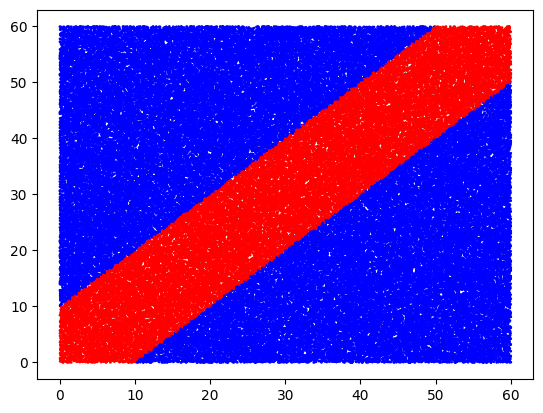

In [ ]:
plt.scatter(x,y,c=encuentro,s=1)
plt.show()

Romeo y Julieta se encuentran si $|x-y| \leq 10$, lo que corrresponde a la franja roja de la grafica anterior, cuya área es $(60)^2 - (50)^2$.
Entonces:
$$ \mathbb{P}(A) = \frac{\text{Área de } A}{\text{Área de } \Omega} $$

$$ \mathbb{P}(A) = \frac{(60)^2 - (50)^2}{(60)^2} = \frac{11}{36} = 0.3056 $$

# Probabilidad frecuentista

Supongamos que se realizan $n$ repeticiones de un cierto experimento aleatorio y que se registra el número de veces que ocurre un determinado evento $A$.

Tenemos la hipótesis de que el espacio muestral es un conjunto finito, y podemos definir la probabilidad asociada a un evento $A$

$$ f_n(A) = \frac{n(A)}{n},$$

donde $n(A)$ denota al numero de veces que ocurre $A$, y $n$ es el número de veces en que se realiza el experimento.

In [68]:
import random

Se tiene el lanzamiento de monedas injustas (volado)

In [69]:
# definimos nuestro experimento aleatorio con una probabilidad p de obtener Sol
def volado(p):
  return 'sol' if random.random() < p else 'aguila'

In [86]:
# Tenemos una probabilidad de 0.4 de que salga Sol
# Realizamos una vez el experimento
volado(0.4)

'aguila'

In [87]:
# Asignamos una probabilidad de 0.4 de obtener sol
# Realizamos 10 veces el experimento (volado)
a = [volado(0.4) for i in range(10)]
print(a)

['aguila', 'sol', 'sol', 'aguila', 'sol', 'aguila', 'aguila', 'sol', 'aguila', 'aguila']


In [88]:
# Contamos las veces que salio Sol
a.count("sol")

4

Otra manera de realizarlo:

In [89]:
resultados = [] #Lista vacia

In [90]:
for i in range(10):
  resultado = volado(0.4)
  resultados.append(resultado)
print(resultados)

['aguila', 'aguila', 'sol', 'aguila', 'aguila', 'aguila', 'sol', 'sol', 'sol', 'aguila']


In [91]:
# Vamos a simular nuestra probabilidad frecuentista
p = [] #lista para almacenar las probabilidades
n_experimentos = 1000 # Simula 1000 experimentos

for i in range(n_experimentos):
  N = 10 # Número de lanzamientos
  resultados = []

  for i in range(N):
    resultado = volado(0.63) # Le asignamos una probabilidad de 0.63 de obtener Sol
    resultados.append(resultado)

  n_soles = resultados.count('sol') #Cuenta el numero de soles
  p_soles = n_soles / N #calcula la proporción

  p.append(p_soles)

p_soles_prom = sum(p) / n_experimentos # Calcula la probabilidad de obtener Sol despues de n lanzamientos

print("Probabilidad de obtener Sol {:.3f}".format(p_soles_prom))

Probabilidad de obtener Sol 0.634


Si definimos el evento $A$ como la probabilidad de obtener Sol en un volado injusto, en este ejemplo le asignamos una probabilidad de 0.63. Al repetir el experimento $n$ veces, notamos que $\mathbb{P}(A)$ converge a este número. Por lo tanto, podemos decir que, sin importar cuántas veces se repita el experimento, $\mathbb{P}(A)$ siempre se aproximará a la probabilidad de un solo experimento.